In [11]:
import pandas as pd
import numpy as np



print("Hello, World!")

Hello, World!


In [12]:
df_elect = pd.read_csv('/home/habeebullah/Documents/Industrial training/demand-response/credentials/data.csv')
df_elect.head()

,CONS_NO,FLAG,2014/1/1,2014/1/10,2014/1/11,2014/1/12,2014/1/13,2014/1/14,2014/1/15,2014/1/16,...,2016/9/28,2016/9/29,2016/9/3,2016/9/30,2016/9/4,2016/9/5,2016/9/6,2016/9/7,2016/9/8,2016/9/9
0,0387DD8A07E07FDA6271170F86AD9151,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.12,9.96,16.92,7.60,27.22,18.05,26.47,18.75,17.84,14.92
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B32AC8CC6D5D805AC053557AB05F5343,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.50,9.99,11.78,18.59,26.80,18.57,14.59,12.82,19.37,15.92
4,EDFC78B07BA2908B3395C4EB2304665E,1,2.9,3.42,3.81,4.58,3.56,4.25,3.86,3.53,...,17.77,10.37,15.32,13.51,12.23,14.68,16.35,18.14,18.41,17.31


In [13]:
df_elect.info()

<class 'pandas.DataFrame'>
RangeIndex: 42372 entries, 0 to 42371
Columns: 1036 entries, CONS_NO to 2016/9/9
dtypes: float64(1034), int64(1), str(1)
memory usage: 334.9 MB


SGCC DATA QUALITY REPORT

[5] Duplicate columns
    Suspected (pandas-renamed) duplicates: 0
    Truly duplicate column names: []

[6] Non-numeric consumption columns
    Count: 1
    Examples: ['CONS_NO']

[7] Negative values
    Total negative readings across dataset: 0
    Columns affected: 0

[8] Row-wise (per-customer) missingness
    Mean missing %: 25.62  |  Max: 99.90  |  Median: 10.63
    Customers with >50% missing days: 11184
    Customers with >80% missing days: 194

[9] Duplicate customer IDs
    Duplicate IDs found: 0



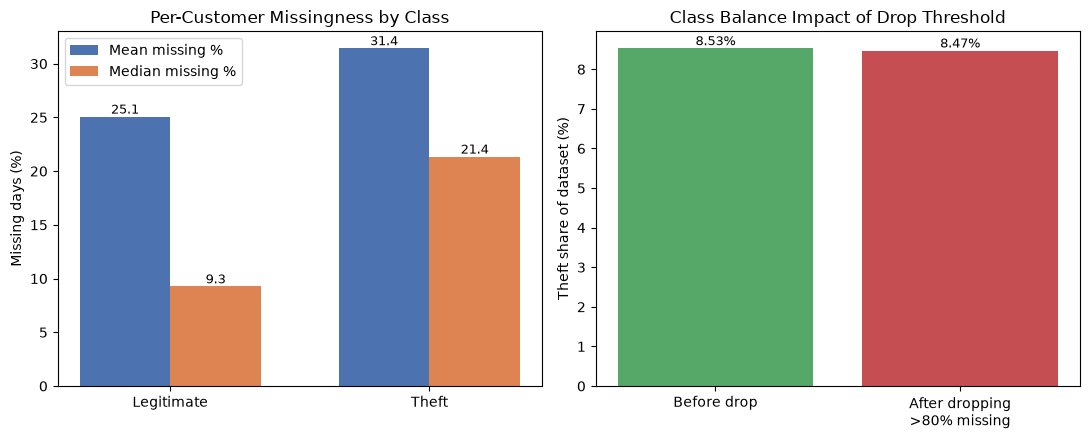

Saved to missingness.png


In [14]:

from sgcc_quality_checks import run_quality_checks, print_report, check_missingness_by_class, plot_missingness_by_class


report = run_quality_checks(df_elect)
print_report(report)
result = check_missingness_by_class(df_elect, label_col="FLAG")
plot_missingness_by_class(result, save_path="missingness.png")

In [15]:
from clean_dataset import run_full_cleaning

print(df_elect.index.name)
print(df_elect.columns[:3])
df_elect = df_elect.set_index('CONS_NO')
df_cleaned = run_full_cleaning(df_elect)


None
Index(['CONS_NO', 'FLAG', '2014/1/1'], dtype='str')
Step 1: fixing date order...
Step 2: dropping sparse customers...
Dropped 195 customers (>80% missing). Remaining: 42177
Step 3: interpolating remaining gaps...
Remaining NaNs after interpolation + fill: 0
Final shape: (42177, 1035)  |  Theft share: 8.47%


In [16]:
from feature_engineering import engineer_features

df_features = engineer_features(df_cleaned)
df_features.head()

Feature table shape: (42177, 13)
Features: ['mean', 'std', 'median', 'max', 'min', 'peak_to_mean', 'skewness', 'pct_zero_days', 'weekday_mean', 'weekend_mean', 'weekday_weekend_ratio', 'mean_rolling7_std']
NaNs remaining: 0


,mean,std,median,max,min,peak_to_mean,skewness,pct_zero_days,weekday_mean,weekend_mean,weekday_weekend_ratio,mean_rolling7_std,FLAG
CONS_NO,,,,,,,,,,,,,
0387DD8A07E07FDA6271170F86AD9151,8.142374,9.528499,6.533504,46.49,0.00,5.709637,1.291061,0.405222,7.946724,8.632495,0.920559,1.803397,1
01D6177B5D4FFE0CABA9EF17DAFC2B84,0.000000,0.000000,0.000000,0.00,0.00,5.861104,1.453035,1.000000,0.000000,0.000000,0.983260,0.000000,1
4B75AC4F2D8434CFF62DB64D0BB43103,2.688317,5.621834,0.000000,32.81,0.00,12.204661,2.414284,0.766925,2.672577,2.727747,0.979774,0.441523,1
B32AC8CC6D5D805AC053557AB05F5343,7.021838,10.731026,0.000000,52.76,0.00,7.513703,1.526543,0.521277,7.043887,6.966601,1.011094,1.918804,1
EDFC78B07BA2908B3395C4EB2304665E,8.259923,5.934754,6.280000,43.43,0.85,5.257918,2.584577,0.000000,8.040697,8.809102,0.912771,1.677012,1


In [17]:
from random_forest_baseline import run_baseline_pipeline




rf, X_train, X_test, y_train, y_test, results = run_baseline_pipeline(df_features)

Train: 33741 customers | Theft %: 8.47
Test:  8436 customers | Theft %: 8.48
RANDOM FOREST BASELINE - TEST SET PERFORMANCE
              precision    recall  f1-score   support

  Legitimate       0.94      0.94      0.94      7721
       Theft       0.31      0.31      0.31       715

    accuracy                           0.88      8436
   macro avg       0.62      0.62      0.62      8436
weighted avg       0.88      0.88      0.88      8436

Confusion matrix:
                Pred Legit   Pred Theft
Actual Legit    7226         495
Actual Theft    496          219

ROC-AUC: 0.7379
F1 (theft class): 0.3065

Feature importances:
std                      0.145230
max                      0.122398
mean_rolling7_std        0.099917
peak_to_mean             0.097991
skewness                 0.087790
pct_zero_days            0.079698
weekend_mean             0.078321
weekday_weekend_ratio    0.077797
weekday_mean             0.077101
mean                     0.076830
median                

In [18]:
from parameter_tuning import tune_rf
from random_forest_baseline import evaluate_rf

best_rf, best_params, best_score = tune_rf(X_train, y_train, n_iter=25)
results = evaluate_rf(best_rf, X_test, y_test)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best theft-F1 (CV): 0.2979
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}
RANDOM FOREST BASELINE - TEST SET PERFORMANCE
              precision    recall  f1-score   support

  Legitimate       0.94      0.85      0.90      7721
       Theft       0.22      0.46      0.30       715

    accuracy                           0.82      8436
   macro avg       0.58      0.66      0.60      8436
weighted avg       0.88      0.82      0.85      8436

Confusion matrix:
                Pred Legit   Pred Theft
Actual Legit    6579         1142
Actual Theft    385          330

ROC-AUC: 0.7463
F1 (theft class): 0.3018

Feature importances:
std                      0.171712
max                      0.135846
peak_to_mean             0.098559
mean_rolling7_std        0.094432
skewness                 0.080378
pct_zero_days            0.0

In [19]:
from parameter_tuning import tune_rf_round2_f2
from random_forest_baseline import evaluate_rf

best_rf_v2, best_params_v2, best_score_v2 = tune_rf_round2_f2(X_train, y_train, n_iter=30)
results_v2 = evaluate_rf(best_rf_v2, X_test, y_test)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best theft-F2 (CV): 0.4046
Best params: {'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}
RANDOM FOREST BASELINE - TEST SET PERFORMANCE
              precision    recall  f1-score   support

  Legitimate       0.96      0.65      0.77      7721
       Theft       0.15      0.69      0.25       715

    accuracy                           0.65      8436
   macro avg       0.56      0.67      0.51      8436
weighted avg       0.89      0.65      0.73      8436

Confusion matrix:
                Pred Legit   Pred Theft
Actual Legit    4999         2722
Actual Theft    219          496

ROC-AUC: 0.7509
F1 (theft class): 0.2522

Feature importances:
std                      0.245608
max                      0.193903
peak_to_mean             0.107531
mean_rolling7_std        0.073939
weekend_mean           

In [21]:
from attack_evaluation import (
    get_raw_readings, nnp_attack, white_box_attack, black_box_attack,
    evaluate_attack, make_query_fn
)

# Get raw readings for theft-labeled customers in your test set only
theft_test_ids = y_test[y_test == 1].index
raw_readings, date_cols = get_raw_readings(df_cleaned, theft_test_ids)

print("=== GRAY-BOX: NNP-style neighbor smoothing ===")
nnp_out = nnp_attack(raw_readings, window=3)
nnp_results = evaluate_attack(nnp_out, y_test.loc[theft_test_ids], best_rf)

print("\n=== WHITE-BOX: targeted peak dampening ===")
wb_out = white_box_attack(raw_readings, top_pct=0.15)
wb_results = evaluate_attack(wb_out, y_test.loc[theft_test_ids], best_rf)

print("\n=== BLACK-BOX: query-based search ===")
theft_test_ids = y_test[y_test == 1].index
raw_readings, date_cols = get_raw_readings(df_cleaned, theft_test_ids)

bb_out = black_box_attack(raw_readings, best_rf, batch_size=25, max_rounds=15, patience=5)
bb_results = evaluate_attack(bb_out, y_test.loc[theft_test_ids], best_rf)

=== GRAY-BOX: NNP-style neighbor smoothing ===
Theft customers attacked: 715
Successfully evaded detection: 420 (58.7%)
Mean theft-probability after attack: 0.4480

=== WHITE-BOX: targeted peak dampening ===
Theft customers attacked: 715
Successfully evaded detection: 533 (74.5%)
Mean theft-probability after attack: 0.3684

=== BLACK-BOX: query-based search ===
Round 1/15: 715 customers still improving, mean theft-prob so far = 0.4574
Round 2/15: 715 customers still improving, mean theft-prob so far = 0.4353
Round 3/15: 715 customers still improving, mean theft-prob so far = 0.4203
Round 4/15: 715 customers still improving, mean theft-prob so far = 0.4096
Round 5/15: 670 customers still improving, mean theft-prob so far = 0.4025
Round 6/15: 588 customers still improving, mean theft-prob so far = 0.3969
Round 7/15: 509 customers still improving, mean theft-prob so far = 0.3932
Round 8/15: 420 customers still improving, mean theft-prob so far = 0.3898
Round 9/15: 342 customers still impr

In [22]:
from random_forest_baseline import train_rf_baseline

baseline_rf = train_rf_baseline(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)
y_proba_baseline = baseline_rf.predict_proba(X_test)[:, 1]

In [23]:
from significance_testing import compare_all_attacks

results_dict = {
    "White-box": wb_results,
    "Gray-box": nnp_results,
    "Black-box": bb_results,
}
compare_all_attacks(y_test, theft_test_ids, results_dict)

BOOTSTRAP CONFIDENCE INTERVALS
White-box: evasion rate = 74.5%  [95% CI: 71.3% - 77.8%]
Gray-box: evasion rate = 58.7%  [95% CI: 55.1% - 62.2%]
Black-box: evasion rate = 71.2%  [95% CI: 67.7% - 74.5%]

PAIRWISE MCNEMAR'S TESTS
McNemar's test: White-box vs Gray-box
  Both evaded: 393 | White-box only: 140 | Gray-box only: 27 | Neither: 155
  Statistic: 75.1138  p-value: 0.0000
  -> Significant difference (p < 0.05): the gap between these attacks is unlikely to be noise.

McNemar's test: White-box vs Black-box
  Both evaded: 465 | White-box only: 68 | Black-box only: 44 | Neither: 138
  Statistic: 4.7232  p-value: 0.0298
  -> Significant difference (p < 0.05): the gap between these attacks is unlikely to be noise.

McNemar's test: Gray-box vs Black-box
  Both evaded: 400 | Gray-box only: 20 | Black-box only: 109 | Neither: 186
  Statistic: 20.0000  p-value: 0.0000
  -> Significant difference (p < 0.05): the gap between these attacks is unlikely to be noise.



In [25]:
from xgb_generalization import run_xgb_generalization_study

xgb_results = run_xgb_generalization_study(
    df_cleaned, X_train, y_train, X_test, y_test, feature_order=list(X_train.columns)
)

Training XGBoost detector...



XGBOOST BASELINE PERFORMANCE
RANDOM FOREST BASELINE - TEST SET PERFORMANCE
              precision    recall  f1-score   support

  Legitimate       0.94      0.84      0.89      7721
       Theft       0.21      0.46      0.29       715

    accuracy                           0.81      8436
   macro avg       0.58      0.65      0.59      8436
weighted avg       0.88      0.81      0.84      8436

Confusion matrix:
                Pred Legit   Pred Theft
Actual Legit    6489         1232
Actual Theft    385          330

ROC-AUC: 0.7383
F1 (theft class): 0.2899

Feature importances:
std                      0.208689
peak_to_mean             0.096970
max                      0.090491
pct_zero_days            0.079856
weekend_mean             0.075017
median                   0.071978
skewness                 0.070823
mean_rolling7_std        0.069253
weekday_mean             0.066401
weekday_weekend_ratio    0.061649
mean                     0.060434
min                      0.048439


In [ ]:
from report_visualizations import (
    plot_baseline_vs_tuned, plot_confusion_matrix, plot_roc_pr_curves,
    plot_feature_importance, plot_probability_shift
)

# 1. Baseline vs Tuned comparison — needs BOTH models' predictions.
# If you don't still have the untuned baseline's y_pred/y_proba saved, retrain it
# quickly: baseline_rf = train_rf_baseline(X_train, y_train); then predict on X_test.
plot_baseline_vs_tuned(y_test, y_pred_baseline, y_proba_baseline,
                        results["y_pred"], results["y_proba"])

# 2. Confusion matrix (tuned model)
plot_confusion_matrix(y_test, results["y_pred"])

# 3. ROC + Precision-Recall curves
plot_roc_pr_curves(y_test, results["y_proba"])

# 4. Feature importance
plot_feature_importance(results["importances"])

# 5. Probability shift — run once per attack, using theft-only probabilities
theft_test_ids = y_test[y_test == 1].index
proba_before = results["y_proba"][y_test.values == 1]  # tuned model's original scores on theft rows

plot_probability_shift(proba_before, bb_results["y_proba_after"], "Black-box Attack")
plot_probability_shift(proba_before, wb_results["y_proba_after"], "White-box Attack")  # if you saved this
plot_probability_shift(proba_before, nnp_results["y_proba_after"], "Gray-box (NNP) Attack")  # if you saved this

In [ ]:
from report_visualizations import plot_confusion_matrix

plot_confusion_matrix(y_test, y_pred_baseline, 
                       save_path="confusion_matrix_baseline.png",
                       title="Confusion Matrix (Baseline RF)")

In [ ]:
from imbalance import compare_imbalance_strategies

comparison = compare_imbalance_strategies(X_train, y_train, X_test, y_test, weighted_rf=best_rf)